# Week 03 · Image Enhancement — Histogram Equalization
**Course:** Computer Vision (BCSE2022)  
**Instructor:** Bùi Huy Kiên  
**Prepared:** 2025-10-17


## 🎯 Mục tiêu học tập
Sau khi hoàn thành bài học này, sinh viên sẽ có thể:
- Hiểu khái niệm **histogram** và mối liên hệ với **xác suất phân bố mức xám** trong ảnh.  
- Phân biệt được **Histogram Equalization** và **Histogram Matching** (Specification).  
- Áp dụng các phép biến đổi histogram để **nâng cao độ tương phản** của ảnh.  
- Cài đặt thuật toán **Histogram Equalization** và **Histogram Matching** bằng Python.  
- Đọc và phân tích biểu đồ **PDF / CDF** của ảnh trước và sau xử lý.


**Hướng dẫn:**  
- Đặt các ảnh input theo tên ghi trong từng cell hoặc sửa đường dẫn cho phù hợp.  
- Mỗi cell hiển thị ảnh dùng `matplotlib.  
- Sử dụng các thư viên: `opencv-python`, `numpy`, `matplotlib`.
- Nếu được, khuyến khích xây dựng lại các thuật toán sử dụng C++/Python


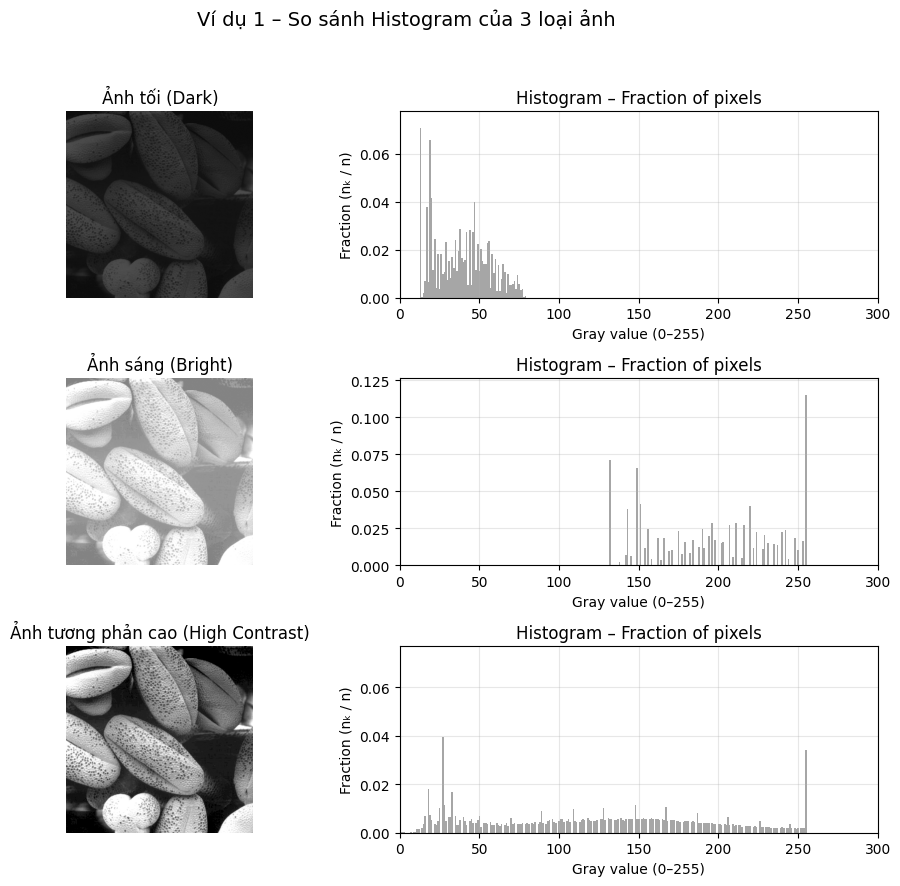

In [2]:
## Ví dụ 1: Biểu diễn Histogram của ảnh

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def compare_three_histograms(img_dark_path, img_bright_path, img_highcontrast_path):
    """
    Đọc vào 3 ảnh (tối, sáng, tương phản cao)
    và vẽ ảnh + histogram của từng ảnh theo dạng subplot 3x2.
    """
    # --- Đọc và chuyển sang grayscale ---
    img_dark = np.asarray(Image.open(img_dark_path).convert("L"))
    img_bright = np.asarray(Image.open(img_bright_path).convert("L"))
    img_high = np.asarray(Image.open(img_highcontrast_path).convert("L"))

    images = [img_dark, img_bright, img_high]
    titles = ["Ảnh tối (Dark)", "Ảnh sáng (Bright)", "Ảnh tương phản cao (High Contrast)"]

    # --- Tạo figure ---
    fig, axes = plt.subplots(3, 2, figsize=(10, 9))

    for i, (img, title) in enumerate(zip(images, titles)):
        # Histogram (chuẩn hóa để hiển thị fraction)
        hist, bins = np.histogram(img.flatten(), bins=256, range=(0, 256))
        p = hist / hist.sum()
        x = bins[:-1]

        # Ảnh
        axes[i, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i, 0].set_title(title)
        axes[i, 0].axis("off")

        # Histogram
        axes[i, 1].bar(x, p, width=1.0, color='gray', alpha=0.7)
        axes[i, 1].set_xlim(0, 300)     # hiển thị 0–300 cho đẹp
        axes[i, 1].set_ylim(0, p.max()*1.1)
        axes[i, 1].set_title(f"Histogram – Fraction of pixels")
        axes[i, 1].set_xlabel("Gray value (0–255)")
        axes[i, 1].set_ylabel("Fraction (nₖ / n)")
        axes[i, 1].grid(alpha=0.3)

    plt.suptitle("Ví dụ 1 – So sánh Histogram của 3 loại ảnh", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# === Cách dùng ===
compare_three_histograms("input/Fig0316(4)(bottom_left).tif", "input/Fig0316(1)(top_left).tif", "input/Fig0320(3)(third_from_top).tif")


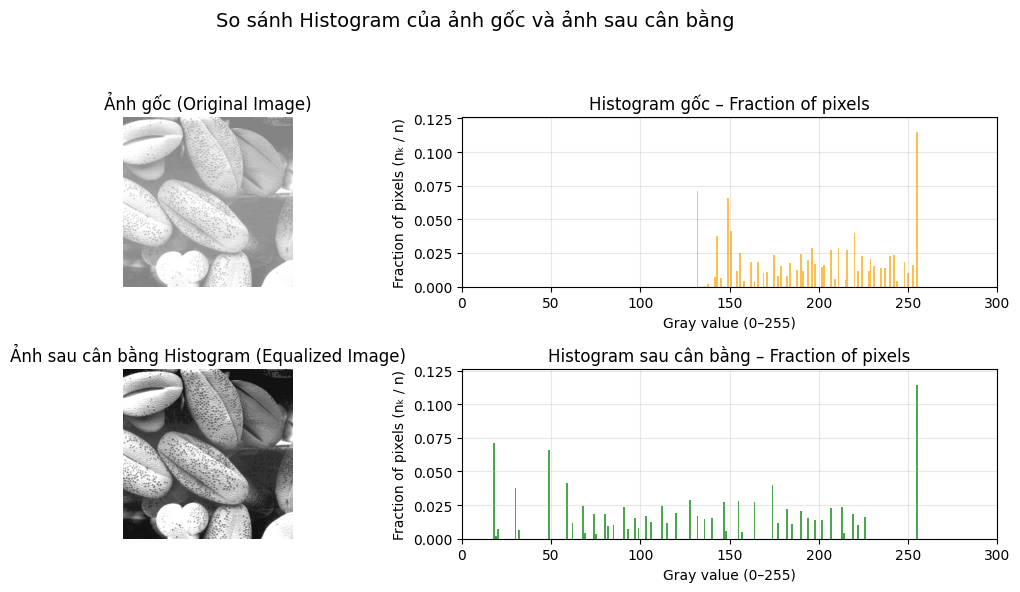

In [3]:
## Ví dụ 2: Histogram Equalization

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ====== HÀM: Histogram Equalization ======
def histogram_equalization(img_gray):
    flat = img_gray.ravel()
    hist = np.bincount(flat, minlength=256)
    cdf = hist.cumsum()
    cdf_norm = (cdf - cdf.min()) / (cdf.max() - cdf.min())
    lut = np.floor(255 * cdf_norm + 0.5).astype(np.uint8)
    return lut[flat].reshape(img_gray.shape)

# ====== HÀM: Vẽ biểu đồ so sánh dạng cột ======
def plot_histograms_compare(image_path):
    # --- Đọc ảnh & chuyển sang grayscale ---
    img = Image.open(image_path).convert("L")
    img = np.asarray(img)

    # --- Cân bằng histogram ---
    img_eq = histogram_equalization(img)

    # --- Tính histogram (256 bins) & chuẩn hóa về fraction of pixels ---
    h_orig, bins = np.histogram(img, bins=256, range=(0, 256))
    h_eq, _ = np.histogram(img_eq, bins=256, range=(0, 256))
    p_orig = h_orig / h_orig.sum()
    p_eq = h_eq / h_eq.sum()

    # --- Chuẩn bị trục x và giới hạn y ---
    x = bins[:-1]
    y_max = max(p_orig.max(), p_eq.max()) * 1.1

    # --- VẼ ---
    fig, axes = plt.subplots(2, 2, figsize=(11, 6))

    # Ảnh gốc
    axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title("Ảnh gốc (Original Image)")
    axes[0, 0].axis("off")

    # Histogram gốc
    axes[0, 1].bar(x, p_orig, width=1.0, color="orange", alpha=0.7)
    axes[0, 1].set_xlim(0, 300)
    axes[0, 1].set_ylim(0, y_max)
    axes[0, 1].set_title("Histogram gốc – Fraction of pixels")
    axes[0, 1].set_xlabel("Gray value (0–255)")
    axes[0, 1].set_ylabel("Fraction of pixels (nₖ / n)")
    axes[0, 1].grid(alpha=0.3)

    # Ảnh sau equalization
    axes[1, 0].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
    axes[1, 0].set_title("Ảnh sau cân bằng Histogram (Equalized Image)")
    axes[1, 0].axis("off")

    # Histogram sau equalization
    axes[1, 1].bar(x, p_eq, width=1.0, color="green", alpha=0.7)
    axes[1, 1].set_xlim(0, 300)
    axes[1, 1].set_ylim(0, y_max)
    axes[1, 1].set_title("Histogram sau cân bằng – Fraction of pixels")
    axes[1, 1].set_xlabel("Gray value (0–255)")
    axes[1, 1].set_ylabel("Fraction of pixels (nₖ / n)")
    axes[1, 1].grid(alpha=0.3)

    plt.suptitle("So sánh Histogram của ảnh gốc và ảnh sau cân bằng", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# ====== CÁCH DÙNG ======
plot_histograms_compare("input/Fig0316(1)(top_left).tif")


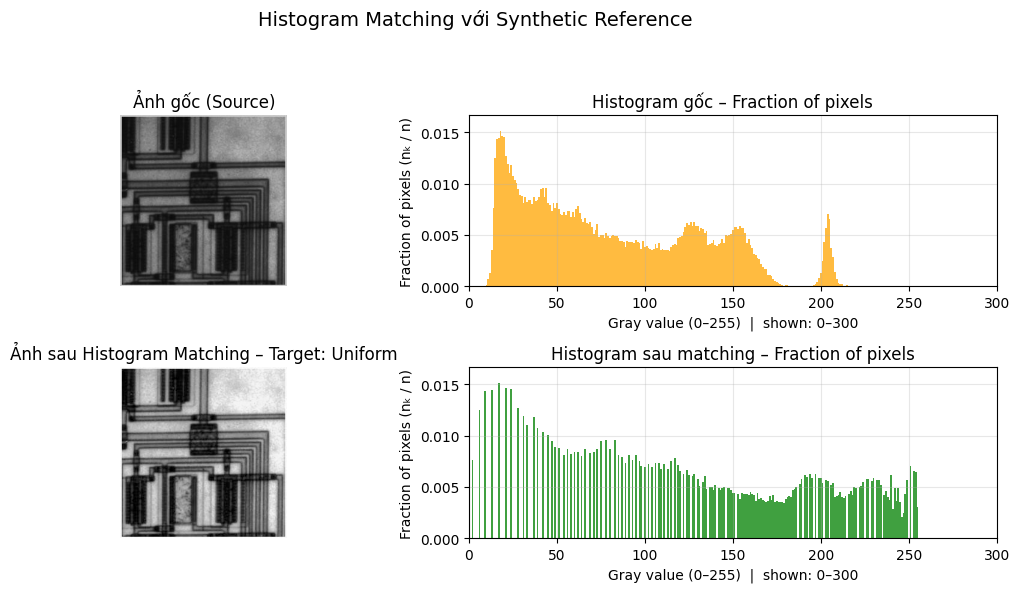

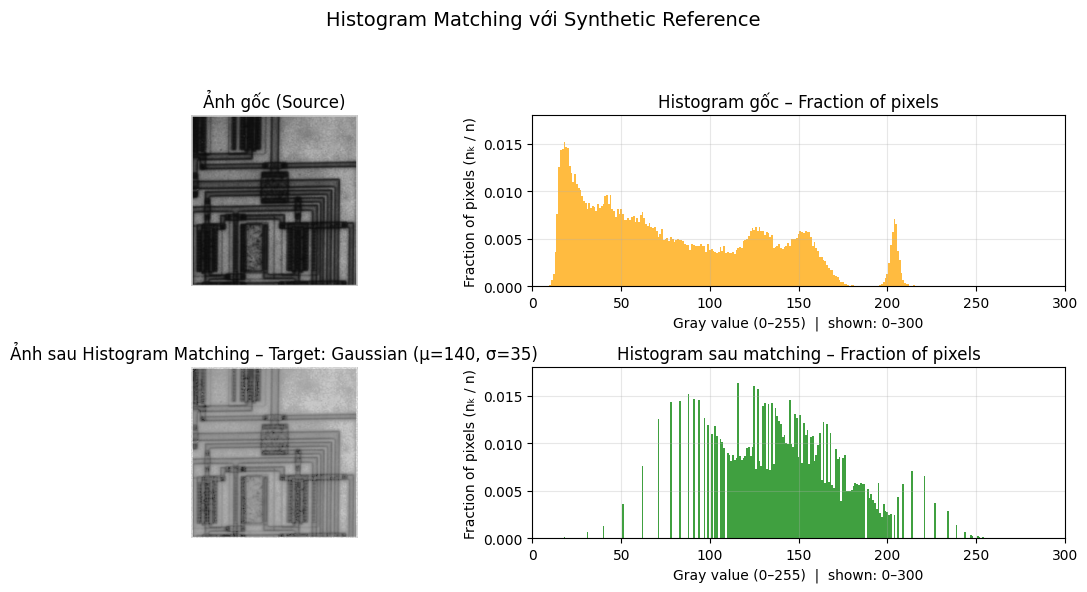

In [4]:
## Ví dụ 3: Histogram Matching

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---------- Synthetic target PDFs ----------
def synthetic_target_pmf(kind="uniform", mu=128.0, sigma=40.0):
    """
    Tạo PMF mục tiêu (256 mức xám) để dùng làm 'reference' ảo.
    kind: "uniform" hoặc "gaussian"
    mu, sigma: tham số cho gaussian (tính trên thang 0..255)
    """
    x = np.arange(256, dtype=np.float64)
    if kind.lower() == "uniform":
        pmf = np.ones_like(x)
    elif kind.lower() == "gaussian":
        # Gaussian không chuẩn hóa sẵn, cần chuẩn hóa về tổng = 1
        pmf = np.exp(-0.5 * ((x - mu) / float(sigma))**2)
    else:
        raise ValueError("kind phải là 'uniform' hoặc 'gaussian'")
    pmf /= pmf.sum()  # chuẩn hóa thành phân bố rời rạc hợp lệ
    return pmf

# ---------- Histogram Matching to target PMF ----------
def histogram_matching_to_pmf(source_gray_uint8, target_pmf):
    """
    Ánh xạ histogram của ảnh nguồn (grayscale uint8) sao cho PMF đầu ra
    tiệm cận target_pmf (độ dài 256).
    """
    # PMF ảnh nguồn
    h_src, _ = np.histogram(source_gray_uint8.ravel(), bins=256, range=(0, 256))
    pmf_src = h_src.astype(np.float64) / h_src.sum()

    # CDF nguồn & CDF đích (synthetic)
    cdf_src = pmf_src.cumsum()
    cdf_tgt = target_pmf.cumsum()

    # LUT: với mỗi r, tìm s sao cho CDF_tgt(s) ≈ CDF_src(r)
    levels = np.arange(256)
    lut = np.interp(cdf_src, cdf_tgt, levels).round().astype(np.uint8)

    # Ánh xạ ảnh
    matched = lut[source_gray_uint8]
    return matched

# ---------- Plot: giữ nguyên form & trục ----------
def plot_histograms_match_synthetic(source_path, kind="uniform", mu=128, sigma=40):
    """
    So sánh ảnh gốc và ảnh sau Histogram Matching theo synthetic target (uniform/gaussian).
    Histogram dùng fraction of pixels, x-axis 0–255 (hiển thị 0–300), cùng thang y.
    """
    # Đọc ảnh (grayscale)
    src = np.asarray(Image.open(source_path).convert("L"))

    # Tạo PMF đích & matching
    tgt_pmf = synthetic_target_pmf(kind=kind, mu=mu, sigma=sigma)
    matched = histogram_matching_to_pmf(src, tgt_pmf)

    # Histogram (fraction)
    h_src, bins = np.histogram(src,     bins=256, range=(0, 256))
    h_mat, _    = np.histogram(matched, bins=256, range=(0, 256))
    p_src = h_src / h_src.sum()
    p_mat = h_mat / h_mat.sum()

    x = bins[:-1]                      # 0..255
    y_max = max(p_src.max(), p_mat.max()) * 1.10

    fig, axes = plt.subplots(2, 2, figsize=(11, 6))

    # Ảnh gốc
    axes[0, 0].imshow(src, cmap="gray", vmin=0, vmax=255)
    axes[0, 0].set_title("Ảnh gốc (Source)")
    axes[0, 0].axis("off")

    # Histogram gốc (fraction)
    axes[0, 1].bar(x, p_src, width=1.0, color="orange", alpha=0.75)
    axes[0, 1].set_xlim(0, 300)
    axes[0, 1].set_ylim(0, y_max)
    axes[0, 1].set_title("Histogram gốc – Fraction of pixels")
    axes[0, 1].set_xlabel("Gray value (0–255)  |  shown: 0–300")
    axes[0, 1].set_ylabel("Fraction of pixels (nₖ / n)")
    axes[0, 1].grid(alpha=0.3)

    # Ảnh sau Histogram Matching (synthetic target)
    title_tgt = f"Uniform" if kind.lower()=="uniform" else f"Gaussian (μ={mu}, σ={sigma})"
    axes[1, 0].imshow(matched, cmap="gray", vmin=0, vmax=255)
    axes[1, 0].set_title(f"Ảnh sau Histogram Matching – Target: {title_tgt}")
    axes[1, 0].axis("off")

    # Histogram sau matching (fraction) – cùng axis/label
    axes[1, 1].bar(x, p_mat, width=1.0, color="green", alpha=0.75)
    axes[1, 1].set_xlim(0, 300)
    axes[1, 1].set_ylim(0, y_max)
    axes[1, 1].set_title("Histogram sau matching – Fraction of pixels")
    axes[1, 1].set_xlabel("Gray value (0–255)  |  shown: 0–300")
    axes[1, 1].set_ylabel("Fraction of pixels (nₖ / n)")
    axes[1, 1].grid(alpha=0.3)

    plt.suptitle("Histogram Matching với Synthetic Reference", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# ===== CÁCH DÙNG =====
# 1) Matching về phân bố đều (Uniform):
plot_histograms_match_synthetic("input/Picture2.jpg", kind="uniform")

# CHÚ Ý: Ở ĐÂY NÊN SỬ DỤNG ẢNH CÓ PHÂN BỐ TỐT ĐỂ THAM CHIẾU
# TRONG VÍ DỤ NAY SỬ DỤNG CÁC PHÂN BỐ TỰ TẠO GỌI LÀ SYNTHETIC REFERENCE

# 2) Matching về phân bố Gaussian (chọn μ, σ theo ảnh tham chiếu mong muốn):
plot_histograms_match_synthetic("input/Picture2.jpg", kind="gaussian", mu=140, sigma=35)
